# Samplers and schedules

A trained diffusion model only tells us, for a noisy image, what it thinks the clean image is. It's the sampler that turns that into a picture: it starts from pure noise and takes a series of steps down the noise levels. In [notebook 01](01-diffusion-from-scratch.ipynb) we wrote DDIM, Euler, DDPM and Heun by hand and talked about how each of them walks back from noise. Here we take the flower model we trained in [notebook 02](02-train-a-diffusion-model.ipynb), run every sampler Dew ships on it, at a few step counts and all from the same starting noise, and time each one.

**Run notebook 02 first, in the same folder, because this notebook loads its checkpoint from `runs/02-diffusion`. It expects one NVIDIA GPU and took about two minutes on an RTX 4080.**

## Install Dependencies

This time we only need Dew and its `cuda13` extra, as this notebook reads no data.

In [ ]:
%pip install -q "dew-ml[cuda13] @ git+https://github.com/AshishKumar4/dew"

## Settings

`STEP_COUNTS` are the numbers of noise levels each sampler walks, and `SAMPLES` is how many images each run draws.

In [1]:
import os

IMAGE_SIZE = 64
CHECKPOINT = "runs/02-diffusion"
STEP_COUNTS = [10, 20, 40]
SAMPLES = 4
SEED = 0

# The tutorial test sets DEW_TUTORIAL_SMOKE=1 to run every cell in minutes on a CPU.
if os.environ.get("DEW_TUTORIAL_SMOKE") == "1":
    STEP_COUNTS, SAMPLES = [2, 4], 2


In [2]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(jax.devices())

[CudaDevice(id=0)]


## Loading the trained model

Remember from notebook 02: a checkpoint holds arrays, not code. So we first rebuild the model and the objective exactly the way notebook 02 built them, and then a `Trainer` over the same objective and the same checkpoint folder restores the latest step with `place()`. We only want the weights here, so the optimizer never takes a step.

In [3]:
import optax
from dew import Checkpoints, Field, InputSpec, Trainer, models, presets
from dew.objectives.diffusion import DiffusionObjective

process = presets.EDM()()
model = models.build(
    "simple_dit",
    patch_size=4,
    emb_features=256,
    num_layers=6,
    num_heads=4,
    output_channels=3,
    dtype="bfloat16",
    attention_impl="auto",
)
objective = DiffusionObjective(model, process, InputSpec(Field("image", (IMAGE_SIZE, IMAGE_SIZE, 3))), ema_decay=0.999)
state, _, _ = Trainer(objective, optax.adamw(3e-4), key=jax.random.key(0),
                      checkpoints=Checkpoints(CHECKPOINT)).place()
print("restored step", int(state.step))

/content/batch/job-1/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resumed from step 6000 in /content/site-tutorials-work/runs/02-diffusion
restored step 6000


## The same starting noise for every sampler

To compare samplers fairly, everything except the sampler has to stay fixed. So we draw the starting noise $x_T$ once and hand the same array to every run. Its spread is about 80, the highest noise level of the EDM schedule. The ancestral samplers (DDPM and Euler ancestral) also add fresh noise at every step; `sample` derives that noise from the `key` we pass, and we pass the same key every time.

In [4]:
x_T = process.noise(jax.random.key(SEED), (SAMPLES, IMAGE_SIZE, IMAGE_SIZE, 3))
print("x_T spread:", float(jnp.std(x_T)))

x_T spread: 80.20647430419922


## The samplers

Here is a quick recap of what each one does. If any of these feel unfamiliar, notebook 01 walks through DDIM, Euler, DDPM and Heun in a lot more detail.

- **DDPM** follows the reverse Markov chain of the original [DDPM paper by Ho et al. (2020)](https://arxiv.org/abs/2006.11239) and adds fresh noise at every step. It needs many small steps.
- **DDIM**, from the [DDIM paper by Song et al. (2020)](https://arxiv.org/abs/2010.02502), is the deterministic version: jump to the next noise level along the direction the model points to.
- **Euler** takes one Euler step of the probability flow ODE per noise level. On this schedule it is the same update as DDIM, just written differently; this is the algebraic equivalence I left as an exercise in notebook 01.
- **Euler ancestral** takes an Euler step to a slightly lower level and then adds back some fresh noise, so it solves the reverse SDE instead of the ODE.
- **Heun** takes an Euler step, asks the model again at the end of it, and averages the two slopes. That costs two model calls per step.
- **RK4** is the classical fourth-order Runge-Kutta method: four model calls per step.
- **MultiStepDPM** reuses the model's answers from the last three steps to correct the current one, at one model call per step.

Each is a small value in `dew.sampling`. As in notebook 02, `process.denoiser(model, params, {})` wraps the model and its weights into the function a sampler calls, and `sample(denoise, x_T, steps, solver=..., key=...)` runs any of the samplers over it in one loop.

In [5]:
from dew.sampling import DDIM, DDPM, RK4, Euler, EulerAncestral, Heun, MultiStepDPM, sample

SOLVERS = {
    "DDPM": DDPM(),
    "DDIM": DDIM(),
    "Euler": Euler(),
    "Euler ancestral": EulerAncestral(),
    "Heun": Heun(),
    "RK4": RK4(),
    "MultiStepDPM": MultiStepDPM(),
}

To time the samplers fairly, we compile each one once with `jax.jit` and time only a second call, otherwise we would mostly be timing XLA's compiler rather than the sampler. The step count and the solver are static arguments, so every combination compiles its own loop. The weights are a normal argument, which keeps them out of the compiled program.

In [6]:
import functools

@functools.partial(jax.jit, static_argnames=("steps", "solver"))
def run(params, x_T, key, steps, solver):
    denoise = process.denoiser(model, params, {})
    return sample(denoise, x_T, steps, solver=solver, key=key)

params = objective.trainable(state.averaged)
images, seconds = {}, {}
for steps in STEP_COUNTS:
    for name, solver in SOLVERS.items():
        run(params, x_T, jax.random.key(SEED), steps, solver).block_until_ready()
        start = time.perf_counter()
        out = run(params, x_T, jax.random.key(SEED), steps, solver).block_until_ready()
        seconds[name, steps] = time.perf_counter() - start
        images[name, steps] = np.asarray(out)

Now let's look at the images. There is one grid per step count. Each row is a sampler and each column one starting noise, so images in the same column started from the same point.

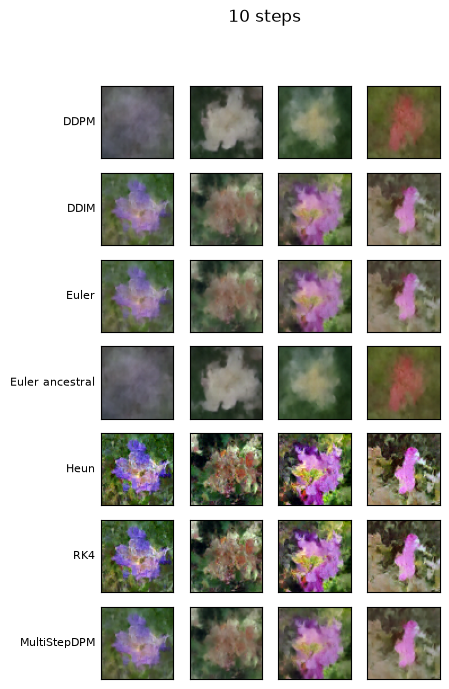

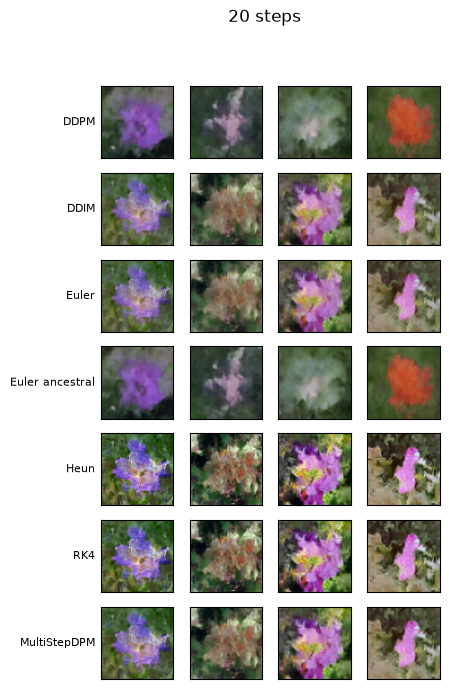

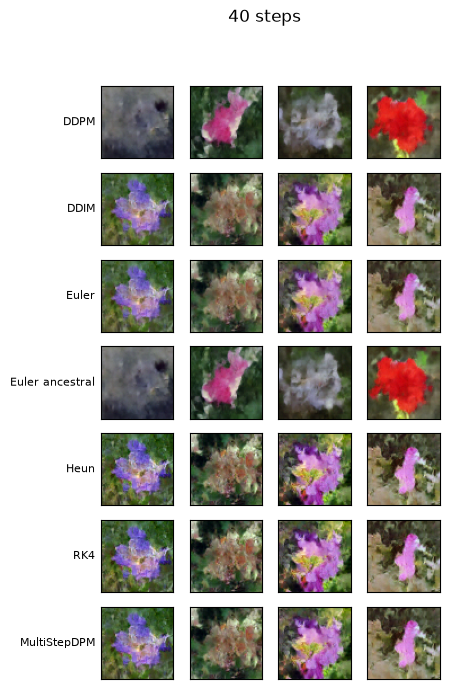

In [7]:
def show_grid(steps):
    figure, axes = plt.subplots(len(SOLVERS), SAMPLES, figsize=(SAMPLES * 1.1, len(SOLVERS) * 1.1))
    for row, name in enumerate(SOLVERS):
        for column in range(SAMPLES):
            axis = axes[row, column]
            axis.imshow(np.clip((images[name, steps][column] + 1) / 2, 0, 1))
            axis.set_xticks([])
            axis.set_yticks([])
        axes[row, 0].set_ylabel(name, rotation=0, ha="right", va="center", fontsize=8)
    figure.suptitle(f"{steps} steps")
    plt.show()

for steps in STEP_COUNTS:
    show_grid(steps)

At 10 steps, DDPM and Euler ancestral leave grey, unfinished images, because the fresh noise they add needs more steps to be removed. Heun and RK4 come out sharper and more contrasty than Euler at 10 steps, which is what we would expect from higher order solvers (remember how Euler's method fell short even for the constant acceleration example in notebook 01?). By 40 steps the deterministic samplers agree closely, and the two ancestral ones have found their own flowers.

## Time per run

The time follows the number of model calls. At 40 steps RK4 takes about three times as long as Euler, and Heun a little under twice as long. At 10 steps each run takes only a few milliseconds, too short for this timer to separate the samplers well.

In [8]:
print(f"{'sampler':<16}" + "".join(f"{steps:>8} steps" for steps in STEP_COUNTS))
for name in SOLVERS:
    print(f"{name:<16}" + "".join(f"{seconds[name, steps] * 1000:>11.0f} ms" for steps in STEP_COUNTS))

sampler               10 steps      20 steps      40 steps
DDPM                      6 ms         11 ms         22 ms
DDIM                      6 ms         11 ms         22 ms
Euler                     6 ms         11 ms         22 ms
Euler ancestral           7 ms         11 ms         22 ms
Heun                     11 ms         21 ms         46 ms
RK4                      19 ms         43 ms         88 ms
MultiStepDPM              7 ms         12 ms         23 ms


## How close the samplers get to each other

The deterministic samplers all solve the same ODE, so with enough steps they should land on nearly the same images. Below is the mean absolute pixel difference between each sampler's images and Euler's at 40 steps, on the `[-1, 1]` scale. The ancestral samplers add their own noise along the way, so they end up at different flowers.

The last line compares the two ancestral samplers with each other: with the same key they give almost the same images, so on this schedule their updates nearly coincide. If you remember notebook 01, that isn't really surprising: DDPM's sampler is equivalent to solving the reverse diffusion SDE with Euler's method, which is exactly what Euler ancestral does.

In [9]:
reference = images["Euler", STEP_COUNTS[-1]]
for name in SOLVERS:
    difference = np.mean(np.abs(images[name, STEP_COUNTS[-1]] - reference))
    print(f"{name:<16} {difference:.4f}")
print("DDPM against Euler ancestral:", np.mean(np.abs(images["DDPM", STEP_COUNTS[-1]] - images["Euler ancestral", STEP_COUNTS[-1]])))

DDPM             0.3645
DDIM             0.0003
Euler            0.0000
Euler ancestral  0.3645
Heun             0.0404
RK4              0.0414
MultiStepDPM     0.0281
DDPM against Euler ancestral: 0.00049281254


## Presets pair a training schedule with a sampling schedule

A sampler walks whatever noise levels the process gives it, and those have to match the ones the model was trained on. That is why Dew keeps both in one `Process`. EDM trains on log-normal noise levels and samples on the Karras grid. The cosine preset trains and samples one discrete schedule with v-prediction, the parameterization from the paper ["Progressive Distillation for Fast Sampling of Diffusion Models" by Salimans and Ho (2022)](https://arxiv.org/abs/2202.00512). The flow preset is rectified flow, from the paper ["Flow Straight and Fast" by Liu et al. (2022)](https://arxiv.org/abs/2209.03003), on both sides.

**Sampling a model with a different process than it trained with walks the wrong path.**

In [10]:
for name in ("edm", "karras", "cosine", "flow"):
    built = presets.build(name)()
    print(f"{name:<7} train: {type(built.schedule).__name__:<24} "
          f"sample: {type(built.sampler_schedule).__name__:<24} "
          f"predicts: {type(built.prediction).__name__}")

edm     train: EDMNoiseScheduler        sample: KarrasVENoiseScheduler   predicts: KarrasPredictionTransform
karras  train: KarrasVENoiseScheduler   sample: KarrasVENoiseScheduler   predicts: KarrasPredictionTransform


cosine  train: CosineNoiseScheduler     sample: CosineNoiseScheduler     predicts: VPredictionTransform
flow    train: FlowMatchingScheduler    sample: FlowMatchingScheduler    predicts: FlowMatchPredictionTransform


## Where to go next

[Notebook 03](03-text-to-image-with-guidance.ipynb) adds a text caption and classifier-free guidance on top of the very same `sample` call.